# **FICO® Xpress MoselPy - Chapter B: Scheduling and Sequencing**

***scheduling_sequencing.ipynb*** - Scheduling problems from the Xpress Applications Book - stadium construction, flow shop, job shop, sequencing, paint production, and assembly line balancing, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
import moselpy as mp
from moselpy import ExecStatus
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/scheduling_sequencing"
DATA   = "data/scheduling_sequencing"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Scheduling problems

This notebook covers six LP and MIP scheduling examples from Chapter B of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from classical project scheduling (CPM), through machine scheduling (flow shop, job shop), to sequencing and assignment problems.

> **Mosel source files:** [`models/scheduling_sequencing/`](models/scheduling_sequencing/) &nbsp;|&nbsp; **Data files:** [`data/scheduling_sequencing/`](data/scheduling_sequencing/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_2)

### MoselPy features demonstrated in this chapter

- **Model introspection**: B-1 demonstrates `model.name`, `model.version`, and `model.size` immediately after `load_model()`, before any `run()` call.
- **DataFrame as 2D input**: B-2 passes the job duration matrix as a `pd.DataFrame` via `input_data`; results retrieved with `find_identifier(use_pandas=True)`.
- **Iterative solving**: B-4 loads the sequencing model once and runs three times with `OBJ=1`, `OBJ=2`, `OBJ=3` via `exec_params`; results collected into a `pd.DataFrame`.
- **Output capture to StringIO**: B-5 redirects Mosel's `writeln` output to a Python string via `moselpy:out`.

## B-1 Stadium construction (LP)

*Applications Book Chapter B, Example 1*

> **Mosel models:** [`b1stadium_p.mos`](models/scheduling_sequencing/b1stadium_p.mos), [`b1stadium2_p.mos`](models/scheduling_sequencing/b1stadium2_p.mos)

A town plans to build a stadium with 18 tasks (plus one fictitious end task). Tasks have precedence relations defined by an adjacency matrix `ARC`. The project is solved in two phases:

1. **Phase 1 - minimum duration (LP):** find the earliest completion time by minimizing `start(N)`.
2. **Phase 2 - project crashing (LP):** given the phase-1 duration, maximize profit by paying to crash (accelerate) individual tasks. Each task has a maximum reduction `MAXW` and a cost `COST`; the builder earns `BONUS` per week of early completion.

**Sets:** $\text{TASKS} = 1..19$ (task 19 is the fictitious end)

**Decision variables:** $\mathit{start}_i \geq 0$ (week task $i$ starts); $\mathit{advance}_i \geq 0$ (weeks task $i$ is accelerated).

$$
\begin{align*}
\text{Phase 1:}\quad \text{minimize}   \quad & \mathit{start}_{19} \\
\text{subject to} \quad & \mathit{start}_j - \mathit{start}_i \geq \text{DUR}_i \quad \forall\,(i,j) \in \text{ARC} \\[6pt]
\text{Phase 2:}\quad \text{maximize}   \quad & \text{BONUS} \cdot \mathit{advance}_{19} - \sum_{i=1}^{18} \text{COST}_i \cdot \mathit{advance}_i \\
\text{subject to} \quad & \mathit{start}_j - \mathit{start}_i + \mathit{advance}_i \geq \text{DUR}_i \quad \forall\,(i,j) \in \text{ARC} \\
                          & \mathit{start}_{19} + \mathit{advance}_{19} = \text{obj1} \\
                          & \mathit{advance}_i \leq \text{MAXW}_i \quad \forall\, i
\end{align*}
$$

Define all input data in Python. `ARC` is passed as a dict of `(i,j)` keys (non-zero entries of the adjacency matrix); `DUR`, `COST`, and `MAXW` are 1-indexed dicts. The model has two `initializations from` blocks but with `DATASOURCE="moselpy:"` both blocks read from the same `input_data` dict.

In [ ]:
N = 19
DUR  = {i+1: v for i,v in enumerate([2,16,9,8,10,6,2,2,9,5,3,2,1,7,4,3,9,1,0])}
COST = {i+1: v for i,v in enumerate([0,30,26,12,17,15,8,0,42,21,18,0,0,22,12,6,16,0,0])}
MAXW = {i+1: v for i,v in enumerate([0,3,1,2,2,1,1,0,2,1,1,0,0,2,2,1,3,0,0])}
BONUS = 30
ARC = {(1,2):1,(2,3):1,(2,4):1,(2,14):1,(3,5):1,(4,6):1,(4,7):1,(4,9):1,(4,10):1,(4,15):1,
       (5,6):1,(6,8):1,(6,9):1,(6,11):1,(7,13):1,(8,16):1,(9,12):1,(10,19):1,(11,16):1,
       (12,17):1,(13,19):1,(14,15):1,(14,16):1,(15,19):1,(16,19):1,(17,18):1,(18,19):1}

Task durations and crashing costs as input data: each bar shows the base duration; tasks eligible for crashing are annotated with their cost per week saved.

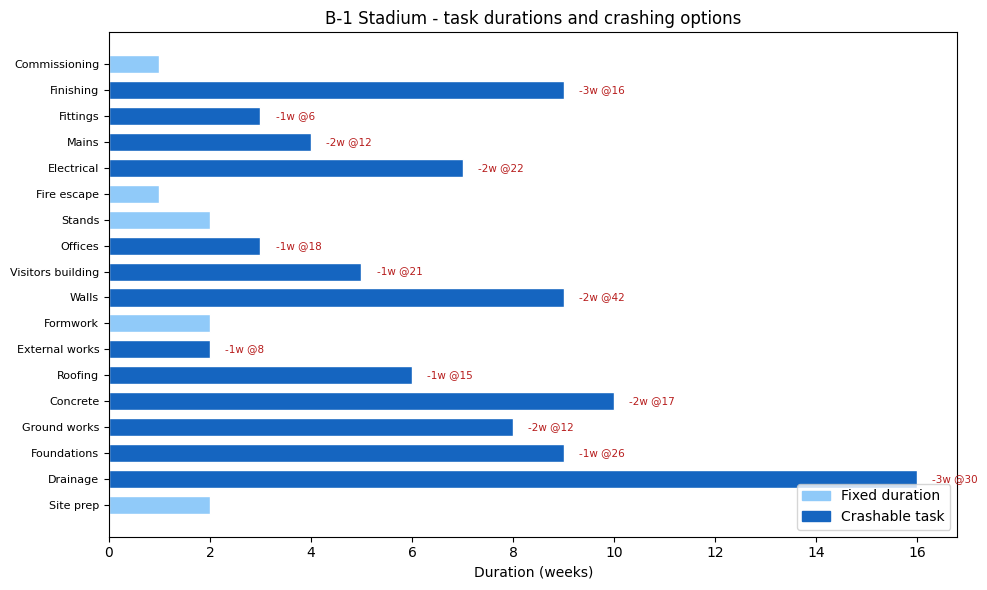

In [ ]:
task_names_viz = ["Site prep","Drainage","Foundations","Ground works","Concrete",
                  "Roofing","External works","Formwork","Walls","Visitors building",
                  "Offices","Stands","Fire escape","Electrical","Mains",
                  "Fittings","Finishing","Commissioning"]
DUR_list  = [DUR[i] for i in range(1, 19)]
COST_list = [COST[i] for i in range(1, 19)]
MAXW_list = [MAXW[i] for i in range(1, 19)]

bar_colors = ["#1565C0" if w > 0 else "#90CAF9" for w in MAXW_list]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(18), DUR_list, color=bar_colors, edgecolor="white", height=0.7)
for i, (d, c, w) in enumerate(zip(DUR_list, COST_list, MAXW_list)):
    if w > 0:
        ax.text(d + 0.3, i, f"-{w}w @{c}", va="center", fontsize=7.5, color="#B71C1C")
ax.set_yticks(range(18)); ax.set_yticklabels(task_names_viz, fontsize=8)
ax.set_xlabel("Duration (weeks)")
ax.set_title("B-1 Stadium - task durations and crashing options")
blue = mpatches.Patch(color="#90CAF9", label="Fixed duration")
dark = mpatches.Patch(color="#1565C0", label="Crashable task")
ax.legend(handles=[blue, dark], loc="lower right")
plt.tight_layout(); plt.show()

Compile and load `b1stadium_p.mos`, then run it. After `load_model()`, `model.name`, `model.version`, and `model.size` are available for model introspection before any `run()` call. The model runs both phases internally and returns `obj1` (phase-1 duration), `obj_val` (phase-2 profit), and the start and advance arrays. `sol_start` is a 2D array indexed by `(run, task)`: run 1 captures the phase-1 schedule (minimum duration); run 2 captures the phase-2 schedule after crashing.

In [ ]:
mp.compile_model(f"{MODELS}/b1stadium_p.mos", f"{MODELS}/b1stadium_p.bim")
model = mp.load_model(f"{MODELS}/b1stadium_p.bim")

print(f"Model name:    '{model.name}'")
print(f"Model version: {model.version}")
print(f"Compiled size: {model.size:,} bytes")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DUR": DUR, "COST": COST, "MAXW": MAXW, "BONUS": BONUS, "ARC": ARC},
)

if model.prob_status.is_solution_available:
    obj1        = output["obj1"]
    obj_val     = output["obj_val"]
    sol_start   = output["sol_start"]    # dict: (run, task) -> start week
    sol_advance = output["sol_advance"]  # dict: task -> weeks advanced

    print(f"\nPhase 1 - minimum project duration: {obj1:.0f} weeks")
    print(f"Phase 2 - maximum builder profit:   {obj_val:.0f}")
    print()
    task_names = ["Site prep", "Drainage", "Foundations", "Ground works", "Concrete",
                  "Roofing", "External works", "Formwork", "Walls", "Visitors building",
                  "Offices", "Stands", "Fire escape", "Electrical", "Mains",
                  "Fittings", "Finishing", "Commissioning"]
    print(f"{'Task':<20} {'Start P1':>8} {'Start P2':>8} {'Advance':>8}")
    for i in range(1, 19):
        name = task_names[i-1] if i <= len(task_names) else f"Task {i}"
        print(f"  {name:<18} {sol_start[(1,i)]:>8.0f} {sol_start[(2,i)]:>8.0f} {sol_advance[i]:>8.1f}")
else:
    print(f"No solution found ({model.prob_status})")

Model name:    'B-1 Stadium construction'
Model version: 0
Compiled size: 9,920 bytes

Phase 1 - minimum project duration: 64 weeks
Phase 2 - maximum builder profit:   87

Task                 Start P1 Start P2  Advance
  Site prep                 0        0      0.0
  Drainage                  2        2      0.0
  Foundations              18       18      1.0
  Ground works             18       18      0.0
  Concrete                 27       26      2.0
  Roofing                  37       34      1.0
  External works           26       54      0.0
  Formwork                 59       52      0.0
  Walls                    43       39      0.0
  Visitors building        26       52      0.0
  Offices                  58       51      0.0
  Stands                   52       48      0.0
  Fire escape              63       56      0.0
  Electrical               18       18      0.0
  Mains                    26       53      0.0
  Fittings                 61       54      0.0
  Finishing 

Gantt chart showing task start times and durations. Tasks with non-zero advance (crashing) are highlighted in dark blue; the red overlay shows the weeks saved.

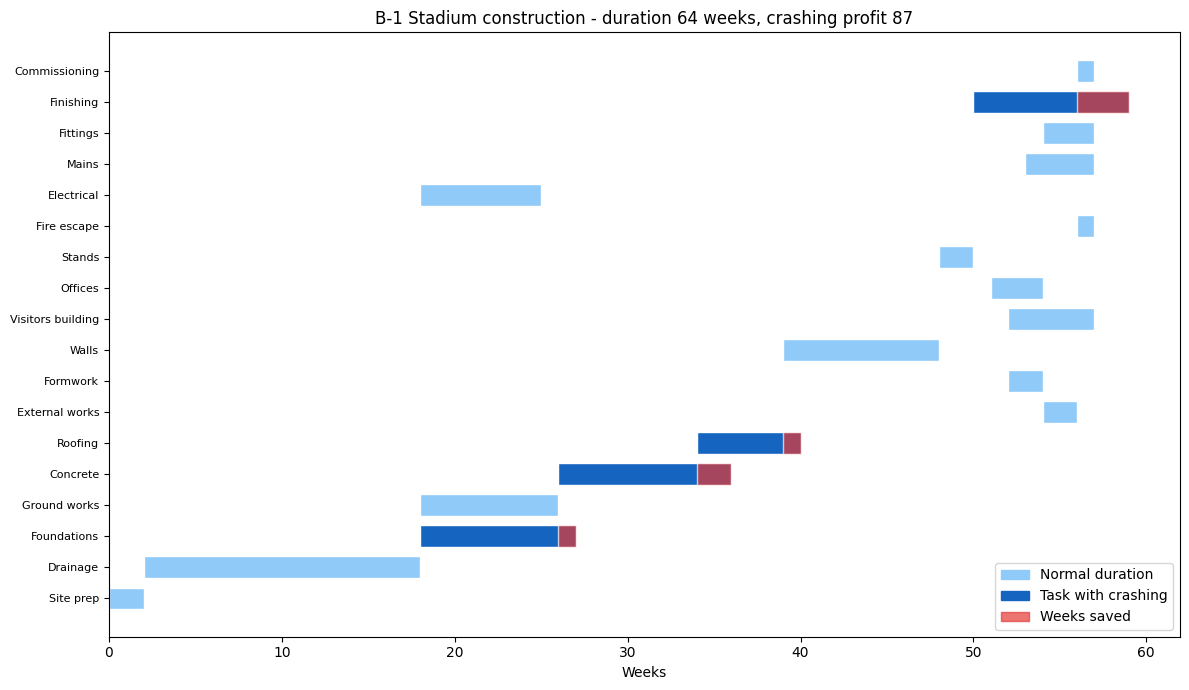

In [ ]:
if "sol_advance" in locals():
    DUR_viz = [2, 16, 9, 8, 10, 6, 2, 2, 9, 5, 3, 2, 1, 7, 4, 3, 9, 1]
    task_names = ["Site prep", "Drainage", "Foundations", "Ground works", "Concrete",
                  "Roofing", "External works", "Formwork", "Walls", "Visitors building",
                  "Offices", "Stands", "Fire escape", "Electrical", "Mains",
                  "Fittings", "Finishing", "Commissioning"]

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ["#1565C0" if sol_advance[i] > 0.01 else "#90CAF9" for i in range(1, 19)]
    for i in range(1, 19):
        ax.barh(i-1, DUR_viz[i-1], left=sol_start[(2,i)], color=colors[i-1], edgecolor="white", height=0.7)
        if sol_advance[i] > 0.01:
            ax.barh(i-1, sol_advance[i], left=sol_start[(2,i)]+DUR_viz[i-1]-sol_advance[i],
                    color="#E53935", edgecolor="white", height=0.7, alpha=0.7)

    ax.set_yticks(range(18))
    ax.set_yticklabels(task_names, fontsize=8)
    ax.set_xlabel("Weeks")
    ax.set_title(f"B-1 Stadium construction - duration {obj1:.0f} weeks, crashing profit {obj_val:.0f}")
    blue_patch = mpatches.Patch(color="#90CAF9", label="Normal duration")
    dark_patch = mpatches.Patch(color="#1565C0", label="Task with crashing")
    red_patch  = mpatches.Patch(color="#E53935", label="Weeks saved", alpha=0.7)
    ax.legend(handles=[blue_patch, dark_patch, red_patch], loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping Gantt chart")

### Set-based formulation

`b1stadium2_p.mos` encodes the same problem using `SUCC: array(TASKS) of set of integer` instead of a dynamic 2D adjacency matrix. The precedence loop becomes `forall(i in TASKS, j in SUCC(i))` rather than iterating over all `(i,j)` pairs with `exists(ARC(i,j))`. Both formulations solve to the same two-phase result.

> **Note:** `b1stadium2_p` reads input from a `.dat` file rather than Python `input_data` because `SUCC: array(TASKS) of set of integer` is not supported by the `moselpy:` driver for Python input.

In [ ]:
mp.compile_model(f"{MODELS}/b1stadium2_p.mos", f"{MODELS}/b1stadium2_p.bim")
out2 = None
with mp.load_model(f"{MODELS}/b1stadium2_p.bim") as model2:
    out2 = model2.run(exec_params={"DATASOURCE": f"{DATA}/b1stadium2_p.dat", "OUTFILE": "moselpy:"})
    sol2_ok = model2.prob_status.is_solution_available

if sol2_ok:
    print(f"[array-based]  Phase 1 duration: {obj1:.0f} w  |  Phase 2 profit: {obj_val:.0f}")
    print(f"[set-based]    Phase 1 duration: {out2['obj1']:.0f} w  |  Phase 2 profit: {out2['obj_val']:.0f}")
    print("Results match:", abs(out2['obj_val'] - obj_val) < 1e-6)
else:
    print("No solution found for b1stadium2_p")

[array-based]  Phase 1 duration: 64 w  |  Phase 2 profit: 87
[set-based]    Phase 1 duration: 64 w  |  Phase 2 profit: 87
Results match: True


## B-2 Flow shop (MIP)

*Applications Book Chapter B, Example 2*

> **Mosel model:** [`b2flowshop_p.mos`](models/scheduling_sequencing/b2flowshop_p.mos)

A workshop produces metal pipes on three machines. Each of six jobs must pass through all three machines in order (machine 1, then 2, then 3). The goal is to find the optimal job sequence (ranking) to minimize the total waiting time on the last machine.

Binary variable $\mathit{rank}_{j,k} = 1$ if job $j$ is processed $k$-th. Continuous variable $\mathit{start}_{m,k}$ gives the start time of the $k$-th ranked job on machine $m$.

**Sets:** $\text{MACH} = 1..3$, $\text{JOBS} = 1..6$, $\text{RANKS} = 1..6$

**Decision variables:** $\mathit{rank}_{j,k} \in \{0,1\}$; $\mathit{start}_{m,k} \geq 0$; $\mathit{empty}_{m,k} \geq 0$; $\mathit{wtime}_{m,k} \geq 0$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{m=1}^{2}\sum_{j} \text{DUR}_{m,j} \cdot \mathit{rank}_{j,1} + \sum_{k=1}^{5} \mathit{empty}_{3,k} \\
\text{subject to} \quad & \sum_j \mathit{rank}_{j,k} = 1 \quad \forall\, k \quad \text{(one job per rank)} \\
                          & \sum_k \mathit{rank}_{j,k} = 1 \quad \forall\, j \quad \text{(one rank per job)} \\
                          & \mathit{empty}_{m,k} + \sum_j \text{DUR}_{m,j}\mathit{rank}_{j,k+1} + \mathit{wtime}_{m,k+1} = \mathit{wtime}_{m,k} + \sum_j \text{DUR}_{m+1,j}\mathit{rank}_{j,k} + \mathit{empty}_{m+1,k}
\end{align*}
$$

The duration matrix `DUR` (3 machines x 6 jobs) is passed from Python as a `pd.DataFrame`. Both `DATASOURCE` and `OUTFILE` are set to `"moselpy:"` so that input data flows in and results flow back through Python in the same call.

Define the 3-by-6 duration matrix as a `pd.DataFrame`. Rows are machines, columns are jobs. Passing a DataFrame directly as `input_data` is a convenient way to supply 2D data - MoselPy maps the row/column indices to the Mosel 2D array.

In [ ]:
dur_data = [[3, 6, 3, 5, 5, 7],
            [5, 4, 2, 4, 4, 5],
            [5, 2, 4, 6, 3, 6]]
dur_df = pd.DataFrame(dur_data, index=[1, 2, 3], columns=[1, 2, 3, 4, 5, 6])
dur_df.index.name   = "Machine"
dur_df.columns.name = "Job"

print("Duration matrix (machine x job):")
print(dur_df.to_string())

Duration matrix (machine x job):
Job      1  2  3  4  5  6
Machine                  
1        3  6  3  5  5  7
2        5  4  2  4  4  5
3        5  2  4  6  3  6


Compile `b2flowshop_p.mos` with the `"g"` debug flag so that all model identifiers - not just `public` ones - are accessible via `find_identifier()`. Pass `DATASOURCE="moselpy:"` and `OUTFILE="moselpy:"` so results are returned in the output dict.

After the run, `model.find_identifier("sol_start", use_pandas=True)` returns a MultiIndex Series keyed by `(machine, rank)`. Calling `.unstack(level=0)` pivots the machine index into columns, producing a rank-by-machine DataFrame of start times.

In [ ]:
mp.compile_model(f"{MODELS}/b2flowshop_p.mos", f"{MODELS}/b2flowshop_p.bim", "g")
model = mp.load_model(f"{MODELS}/b2flowshop_p.bim")
output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DUR": dur_df},
)

if model.prob_status.is_solution_available:
    obj_val = output["obj_val"]
    print(f"Total waiting time: {obj_val:.0f}")

    sol_start_df = model.find_identifier("sol_start", use_pandas=True).unstack(level=0)
    sol_start_df.columns = [f"Machine {m}" for m in sol_start_df.columns]
    sol_start_df.index   = [f"Rank {k}"    for k in sol_start_df.index]
    print(f"\nStart times (rank x machine):")
    print(sol_start_df.round(1).to_string())
else:
    print(f"No solution found ({model.prob_status})")

Total waiting time: 9

Start times (rank x machine):
        Machine 1  Machine 2  Machine 3
Rank 1        0.0        3.0        8.0
Rank 2        3.0       11.0       13.0
Rank 3        6.0       13.0       18.0
Rank 4       13.0       20.0       24.0
Rank 5       18.0       25.0       30.0
Rank 6       23.0       29.0       33.0


Gantt chart with machines as rows. Each colored block represents one job (colored by job index) starting at `sol_start[machine, rank]` with width `DUR[machine, job]`.

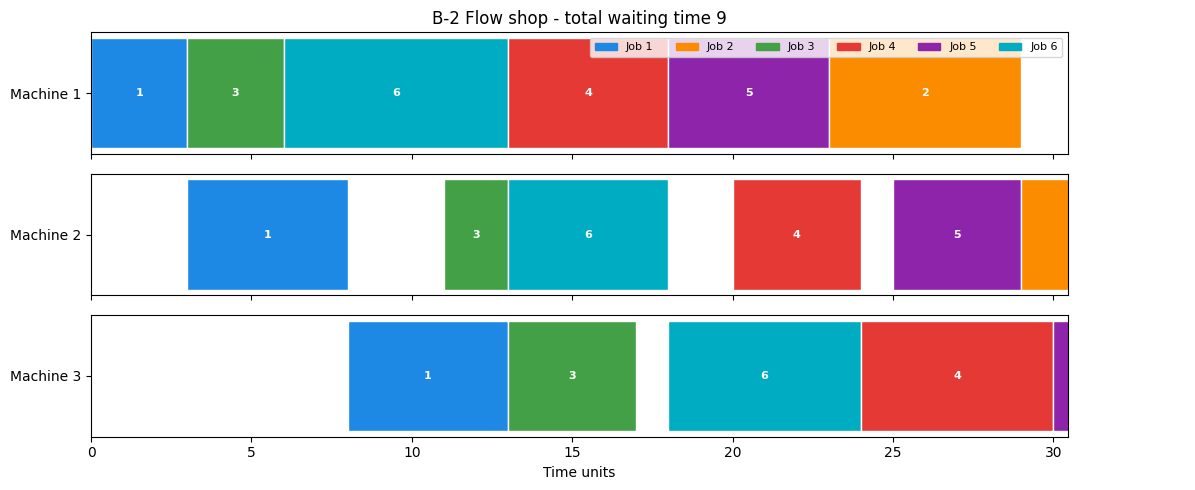

In [ ]:
if "sol_start_df" in locals():
    NM, NJ = 3, 6
    job_colors = ["#1E88E5", "#FB8C00", "#43A047", "#E53935", "#8E24AA", "#00ACC1"]

    sol_rank  = output["sol_rank"]   # dict: (job, rank) -> real
    job_order = [round(sum(j * sol_rank.get((j, k), 0) for j in range(1, NJ+1)))
                 for k in range(1, NJ+1)]

    fig, axes = plt.subplots(NM, 1, figsize=(12, 5), sharex=True)
    for m_idx, m in enumerate(range(1, NM+1)):
        ax = axes[m_idx]
        for k_idx, k in enumerate(range(1, NJ+1)):
            job = job_order[k_idx]
            s   = sol_start_df.iloc[k_idx, m_idx]
            d   = dur_data[m-1][job-1]
            ax.barh(0, d, left=s, color=job_colors[job-1], edgecolor="white", height=0.5)
            ax.text(s + d/2, 0, str(job), ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax.set_yticks([0]); ax.set_yticklabels([f"Machine {m}"])
        ax.set_xlim(0, None)

    axes[-1].set_xlabel("Time units")
    handles = [mpatches.Patch(color=job_colors[j-1], label=f"Job {j}") for j in range(1, NJ+1)]
    axes[0].legend(handles=handles, loc="upper right", ncol=NJ, fontsize=8)
    axes[0].set_title(f"B-2 Flow shop - total waiting time {obj_val:.0f}")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping flow shop Gantt chart")

## B-3 Job shop (MIP)

*Applications Book Chapter B, Example 3*

> **Mosel models:** [`b3jobshop_p.mos`](models/scheduling_sequencing/b3jobshop_p.mos), [`b3jobshop2_p.mos`](models/scheduling_sequencing/b3jobshop2_p.mos), [`b3jobshop3_p.mos`](models/scheduling_sequencing/b3jobshop3_p.mos)

Three types of wallpaper (jobs) are processed on three machines (printing colors). Each job visits machines in a job-specific order. Jobs that share a machine cannot overlap - these are the disjunctive constraints. All three formulations minimize the same makespan (`finish`).

- `b3jobshop_p.mos`: 8 operations, precedence graph `ARC` and disjunctions `DISJ` as dynamic arrays.
- `b3jobshop2_p.mos`: generic formulation, `DUR` indexed by `(machine, job)`, explicit `NUMT`/`SEQ`/`NUMD`/`DISJ` arrays.
- `b3jobshop3_p.mos`: compact formulation using `array of list` for job sequences and `array of set` for disjunctive groups.

**Sets:** $\text{JOBS} = 1..8$ (operations), machines implicit in precedence/disjunction data.

**Decision variables:** $\mathit{start}_j \geq 0$ (start time of operation $j$); $\mathit{finish} \geq 0$ (makespan); $y_d \in \{0,1\}$ (disjunction direction).

$$
\begin{align*}
\text{minimize}   \quad & \mathit{finish} \\
\text{subject to} \quad & \mathit{finish} \geq \mathit{start}_j + \text{DUR}_j \quad \forall\, j \\
                          & \mathit{start}_i + \text{DUR}_i \leq \mathit{start}_j \quad \forall\,(i,j) \in \text{ARC} \quad \text{(precedence)} \\
                          & \mathit{start}_i + \text{DUR}_i \leq \mathit{start}_j + M \cdot y_d \quad \forall\,(i,j) \in \text{DISJ} \quad \text{(disjunction)} \\
                          & \mathit{start}_j + \text{DUR}_j \leq \mathit{start}_i + M \cdot (1-y_d) \quad \forall\,(i,j) \in \text{DISJ}
\end{align*}
$$

Define input data for `b3jobshop_p` and `b3jobshop2_p` in Python. Both models are passed via `DATASOURCE="moselpy:"` and `input_data`. `b3jobshop3_p` reads from a `.dat` file - see the note below.

In [ ]:
# b3jobshop_p: 8 operations, precedence graph ARC, disjunctions DISJ
DUR_J  = {i+1: v for i,v in enumerate([45,20,12,10,17,10,34,28])}
ARC_J  = {(1,6):1,(4,2):1,(2,7):1,(8,3):1,(3,5):1}
DISJ_J = {(1,2):1,(1,3):1,(2,3):1,(4,5):1,(6,7):1,(6,8):1,(7,8):1}

# b3jobshop2_p: generic formulation with DUR(machine,job), sequence and disjunction arrays
DUR2  = {(1,1):45,(1,2):20,(1,3):12,(2,2):10,(2,3):17,(3,1):10,(3,2):34,(3,3):28}
NUMT  = {1:2, 2:3, 3:3}
SEQ2  = {(1,1):1,(1,2):3,(2,1):2,(2,2):1,(2,3):3,(3,1):3,(3,2):1,(3,3):2}
NUMD  = {1:3, 2:2, 3:3}
DISJ2 = {(1,1):1,(1,2):2,(1,3):3,(2,1):2,(2,2):3,(3,1):1,(3,2):2,(3,3):3}

Run all three formulations and compare their makespan values. Since these are equivalent models for the same problem, they must all return the same optimal objective.

In [ ]:
outputs_b3 = {}
results_b3 = []

# b3jobshop_p - data from Python
model, out1 = mp.execute_model(
    f"{MODELS}/b3jobshop_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DUR": DUR_J, "ARC": ARC_J, "DISJ": DISJ_J},
)
outputs_b3["b3jobshop_p"] = out1
results_b3.append({"model": "b3jobshop_p", "makespan": out1["obj_val"]})

# b3jobshop2_p - data from Python
model, out2 = mp.execute_model(
    f"{MODELS}/b3jobshop2_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DUR": DUR2, "NUMT": NUMT, "SEQ": SEQ2, "NUMD": NUMD, "DISJ": DISJ2},
)
outputs_b3["b3jobshop2_p"] = out2
results_b3.append({"model": "b3jobshop2_p", "makespan": out2["obj_val"]})

# b3jobshop3_p - reads from .dat file because SEQ: array of list of integer and
# DISJ: array of set of integer are not supported by the moselpy: driver for Python input
model, out3 = mp.execute_model(
    f"{MODELS}/b3jobshop3_p.mos",
    exec_params={"DATASOURCE": f"{DATA}/b3jobshop3_p.dat", "OUTFILE": "moselpy:"},
)
outputs_b3["b3jobshop3_p"] = out3
results_b3.append({"model": "b3jobshop3_p", "makespan": out3["obj_val"]})

df_b3 = pd.DataFrame(results_b3).set_index("model")
print("Job shop formulation comparison:")
print(df_b3.to_string())

Job shop formulation comparison:
              makespan
model                 
b3jobshop_p       97.0
b3jobshop2_p      97.0
b3jobshop3_p      97.0


Gantt chart built from `b3jobshop_p` results. The 8 operations are grouped by paper type (ops 1-2 for paper 1, 3-5 for paper 2, 6-8 for paper 3).

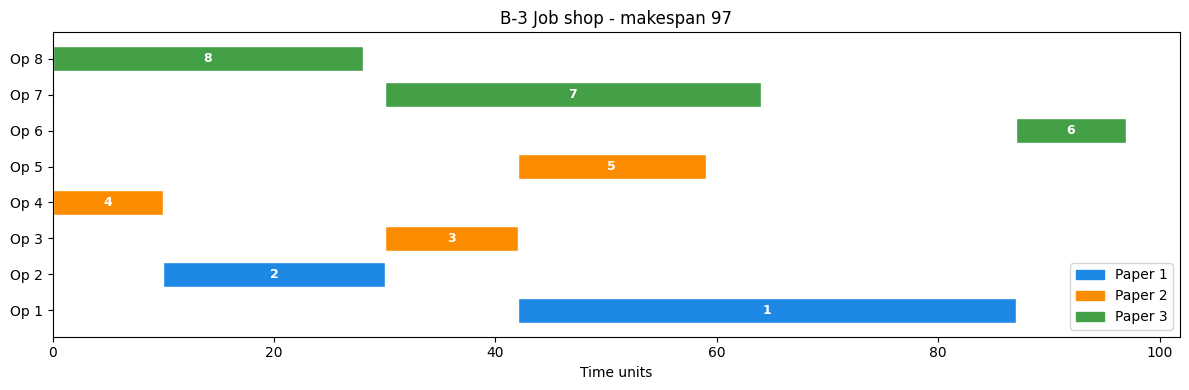

In [ ]:
if "obj_val" in outputs_b3.get("b3jobshop_p", {}):
    sol_start_b3 = outputs_b3["b3jobshop_p"]["sol_start"]  # dict: job (1..8) -> start time
    makespan_b3  = outputs_b3["b3jobshop_p"]["obj_val"]

    DUR_b3    = [45, 20, 12, 10, 17, 10, 34, 28]
    job_paper = [1, 1, 2, 2, 2, 3, 3, 3]
    paper_colors = ["#1E88E5", "#FB8C00", "#43A047"]

    fig, ax = plt.subplots(figsize=(12, 4))
    for j_idx, j in enumerate(range(1, 9)):
        s = sol_start_b3[j]
        d = DUR_b3[j_idx]
        paper = job_paper[j_idx]
        ax.barh(j_idx, d, left=s, color=paper_colors[paper-1], edgecolor="white", height=0.7)
        ax.text(s + d/2, j_idx, str(j), ha="center", va="center", fontsize=9, color="white", fontweight="bold")

    ax.set_yticks(range(8))
    ax.set_yticklabels([f"Op {j}" for j in range(1, 9)])
    ax.set_xlabel("Time units")
    ax.set_title(f"B-3 Job shop - makespan {makespan_b3:.0f}")
    handles = [mpatches.Patch(color=paper_colors[p-1], label=f"Paper {p}") for p in range(1, 4)]
    ax.legend(handles=handles, loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("No solution available for b3jobshop_p - skipping Gantt chart")

## B-4 Sequencing (MIP)

*Applications Book Chapter B, Example 4*

> **Mosel model:** [`b4seq_p.mos`](models/scheduling_sequencing/b4seq_p.mos)

Seven jobs must be sequenced on a single bottleneck machine. Each job has a release date `REL`, duration `DUR`, and due date `DUE`. The model is parameterised by `OBJ` to select between three objectives:

- `OBJ=1`: minimize makespan (total schedule duration).
- `OBJ=2`: minimize total completion time (average completion is proportional).
- `OBJ=3`: minimize total tardiness (sum of lateness above zero).

Binary variable $\mathit{rank}_{j,k} = 1$ if job $j$ is placed at position $k$.

**Sets:** $\text{JOBS} = 1..7$

**Decision variables:** $\mathit{rank}_{j,k} \in \{0,1\}$; $\mathit{start}_k \geq 0$; $\mathit{comp}_k \geq 0$; $\mathit{late}_k \geq 0$; $\mathit{finish} \geq 0$.

$$
\begin{align*}
\text{minimize}   \quad & \begin{cases} \mathit{finish} & \text{if OBJ}=1 \\ \sum_k \mathit{comp}_k & \text{if OBJ}=2 \\ \sum_k \mathit{late}_k & \text{if OBJ}=3 \end{cases} \\
\text{subject to} \quad & \sum_j \mathit{rank}_{j,k} = 1,\quad \sum_k \mathit{rank}_{j,k} = 1 \quad \text{(assignment)} \\
                          & \mathit{start}_{k+1} \geq \mathit{start}_k + \sum_j \text{DUR}_j \cdot \mathit{rank}_{j,k} \quad \text{(sequencing)} \\
                          & \mathit{start}_k \geq \sum_j \text{REL}_j \cdot \mathit{rank}_{j,k} \quad \text{(release dates)}
\end{align*}
$$

Define job data in Python: release dates `REL`, durations `DUR`, and due dates `DUE`, all 1-indexed dicts.

In [ ]:
REL   = {i+1: v for i,v in enumerate([2,5,4,0,0,8,9])}
DUR_S = {i+1: v for i,v in enumerate([5,6,8,4,2,4,2])}
DUE   = {i+1: v for i,v in enumerate([10,21,15,10,5,15,22])}

The model is compiled and loaded once. `run()` is then called three times - each time with a different `OBJ` value via `exec_params`. This is the iterative solving pattern: one compiled model, multiple parametric runs with varying parameters. The same `input_data` dict is reused across all three runs. Results are collected into a `pd.DataFrame` for comparison.

In [ ]:
mp.compile_model(f"{MODELS}/b4seq_p.mos", f"{MODELS}/b4seq_p.bim")
model = mp.load_model(f"{MODELS}/b4seq_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

obj_labels = {1: "Makespan", 2: "Total completion", 3: "Total tardiness"}
rows = []
for obj_id in [1, 2, 3]:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "OBJ": obj_id},
        input_data={"REL": REL, "DUR": DUR_S, "DUE": DUE},
    )
    if model.prob_status.is_solution_available:
        sol_rank  = out["sol_rank"]   # dict: (job, position) -> real
        sol_comp  = out["sol_comp"]   # dict: position -> completion time
        sol_start = out["sol_start"]  # dict: position -> start time
        makespan  = out["makespan"]
        job_seq   = [round(sum(j * sol_rank.get((j, k), 0) for j in range(1, 8))) for k in range(1, 8)]
        rows.append({
            "Objective":        obj_labels[obj_id],
            "Obj value":        out["obj_val"],
            "Makespan":         makespan,
            "Total completion": sum(sol_comp.get(k, 0) for k in range(1, 8)),
            "Job sequence":     str(job_seq),
        })
    else:
        print(f"No solution found for OBJ={obj_id} ({model.prob_status})")

df_b4 = pd.DataFrame(rows).set_index("Objective")
print("B-4 Sequencing - results by objective:")
print(df_b4.to_string())

B-4 Sequencing - results by objective:
                  Obj value  Makespan  Total completion           Job sequence
Objective                                                                     
Makespan               31.0      31.0             118.0  [4, 1, 2, 7, 5, 6, 3]
Total completion      103.0      31.0             103.0  [5, 4, 1, 7, 6, 2, 3]
Total tardiness        18.0      31.0             109.0  [5, 4, 1, 6, 2, 7, 3]


Grouped bar chart comparing the three objective values across different criteria.

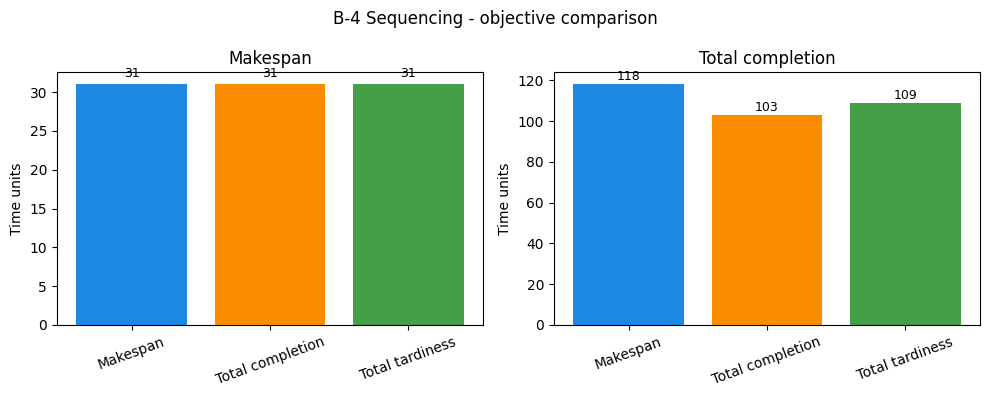

In [ ]:
if not df_b4.empty:
    metrics = ["Makespan", "Total completion"]
    colors  = ["#1E88E5", "#FB8C00", "#43A047"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        vals = [df_b4.loc[obj_labels[i], metric] for i in range(1, 4) if obj_labels[i] in df_b4.index]
        labels = [obj_labels[i] for i in range(1, 4) if obj_labels[i] in df_b4.index]
        bars = ax.bar(labels, vals, color=colors[:len(vals)])
        ax.set_title(metric)
        ax.set_ylabel("Time units")
        ax.tick_params(axis="x", rotation=20)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.0f}", ha="center", va="bottom", fontsize=9)

    plt.suptitle("B-4 Sequencing - objective comparison")
    plt.tight_layout(); plt.show()
else:
    print("No results available - skipping objective comparison chart")

## B-5 Paint production (MIP)

*Applications Book Chapter B, Example 5*

> **Mosel model:** [`b5paint_p.mos`](models/scheduling_sequencing/b5paint_p.mos)

Five paint batches must be produced in a cycle each week. The blender must be cleaned between batches; cleaning time depends on which batch follows which. The problem finds the optimal cyclic sequence (a Hamiltonian circuit / TSP on 5 nodes) to minimize total cycle time.

Binary variable $\mathit{succ}_{i,j} = 1$ if batch $i$ is immediately followed by batch $j$ in the cycle.

**Sets:** $\text{JOBS} = 1..5$

**Decision variables:** $\mathit{succ}_{i,j} \in \{0,1\}$ for $i \neq j$; $y_j \geq 0$ (subtour elimination).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i \neq j} (\text{DUR}_i + \text{CLEAN}_{i,j}) \cdot \mathit{succ}_{i,j} \\
\text{subject to} \quad & \sum_{j \neq i} \mathit{succ}_{i,j} = 1 \quad \forall\, i \quad \text{(one successor per batch)} \\
                          & \sum_{i \neq j} \mathit{succ}_{i,j} = 1 \quad \forall\, j \quad \text{(one predecessor per batch)} \\
                          & y_j \geq y_i + 1 - 5(1 - \mathit{succ}_{i,j}) \quad \forall\, i,\, j \in 2..5,\, i \neq j \quad \text{(subtour elimination)}
\end{align*}
$$

This section demonstrates how to capture Mosel's `writeln` output to a Python string using `StringIO` and the `moselpy:out` driver - useful when the model produces a formatted text report that you want to display or parse in Python.

Define batch data in Python: durations `DUR` and cleaning times `CLEAN` (a 2D dict keyed by `(i,j)` pairs).

In [ ]:
NB = 5
DUR_P = {i+1: v for i,v in enumerate([40,35,45,32,50])}
CLEAN_raw = [[0,11,7,13,11],[5,0,13,15,15],[13,15,0,23,11],[9,13,5,0,3],[3,7,7,7,0]]
CLEAN = {(i+1,j+1): CLEAN_raw[i][j] for i in range(NB) for j in range(NB)}

Heatmap of the cleaning times matrix: each cell shows how long the blender needs cleaning when switching from one paint batch (row) to another (column). Zero on the diagonal means no cleaning when a batch immediately follows itself.

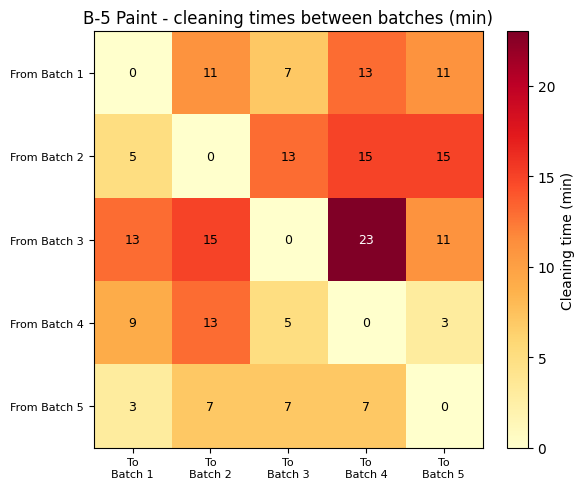

In [ ]:
batch_labels = [f"Batch {i}" for i in range(1, NB+1)]
clean_matrix = [[CLEAN_raw[i][j] for j in range(NB)] for i in range(NB)]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(clean_matrix, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Cleaning time (min)")
ax.set_xticks(range(NB)); ax.set_xticklabels([f"To\n{b}" for b in batch_labels], fontsize=8)
ax.set_yticks(range(NB)); ax.set_yticklabels([f"From {b}" for b in batch_labels], fontsize=8)
for i in range(NB):
    for j in range(NB):
        ax.text(j, i, str(clean_matrix[i][j]), ha="center", va="center", fontsize=9,
                color="white" if clean_matrix[i][j] > 15 else "black")
ax.set_title("B-5 Paint - cleaning times between batches (min)")
plt.tight_layout(); plt.show()

The `moselpy:out` stream driver captures everything Mosel writes to the default output stream into the bound Python object - here a `StringIO` buffer. Set the model's output stream to `"moselpy:out"` and bind the `"out"` symbol to a `StringIO` instance before calling `run()`. After the run, `output_buf.getvalue()` contains all the text the model would have printed to the terminal.

In [ ]:
mp.compile_model(f"{MODELS}/b5paint_p.mos", f"{MODELS}/b5paint_p.bim")
model = mp.load_model(f"{MODELS}/b5paint_p.bim")

output_buf = StringIO()
model.symbols["out"] = output_buf
model.set_default_stream(mp.StreamType.OUTPUT, "moselpy:out")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DUR": DUR_P, "CLEAN": CLEAN},
)

if model.prob_status.is_solution_available:
    obj_val  = output["obj_val"]
    sol_succ = output["sol_succ"]   # dict: (i, j) -> real

    captured = output_buf.getvalue()
    print(f"Minimum cycle time: {obj_val:.0f}")
    print()
    print("Mosel output captured via moselpy:out:")
    print(captured if captured.strip() else "(no output captured - stream was null)")
else:
    print(f"No solution found ({model.prob_status})")

Minimum cycle time: 243

Mosel output captured via moselpy:out:
Minimum cycle time: 243 min
Batch  Duration  Cleaning
  1       40       13
  4       32        5
  3       45       11
  5       50        7
  2       35        5



Reconstruct the production sequence from the `sol_succ` successor matrix and display it as a circular ordering diagram.

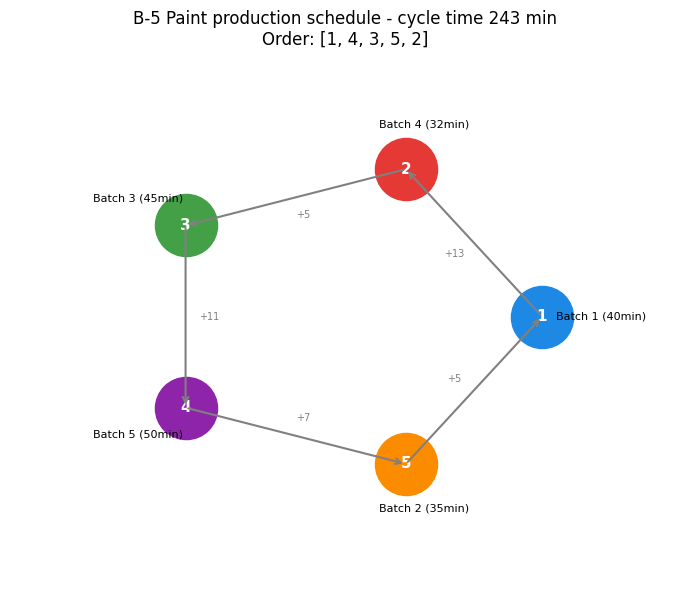

In [ ]:
if "sol_succ" in locals():
    NJ_viz = 5
    DUR_viz   = [40, 35, 45, 32, 50]
    CLEAN_viz = [[ 0, 11,  7, 13, 11],
                 [ 5,  0, 13, 15, 15],
                 [13, 15,  0, 23, 11],
                 [ 9, 13,  5,  0,  3],
                 [ 3,  7,  7,  7,  0]]
    batch_names = ["Batch 1 (40min)", "Batch 2 (35min)", "Batch 3 (45min)",
                   "Batch 4 (32min)", "Batch 5 (50min)"]

    sequence = [1]
    current = 1
    for _ in range(NJ_viz - 1):
        nxt = round(sum(j * sol_succ.get((current, j), 0) for j in range(1, NJ_viz+1) if j != current))
        sequence.append(nxt)
        current = nxt

    fig, ax = plt.subplots(figsize=(7, 6))
    theta = np.linspace(0, 2*np.pi, NJ_viz, endpoint=False)
    xs = np.cos(theta); ys = np.sin(theta)
    colors = ["#1E88E5", "#FB8C00", "#43A047", "#E53935", "#8E24AA"]

    for idx, batch in enumerate(sequence):
        ax.scatter(xs[idx], ys[idx], s=2000, color=colors[batch-1], zorder=3)
        ax.text(xs[idx]*1.3, ys[idx]*1.3, batch_names[batch-1],
                ha="center", va="center", fontsize=8)
        ax.text(xs[idx], ys[idx], str(idx+1), ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

    for idx in range(NJ_viz):
        src = sequence[idx]
        dst = sequence[(idx+1) % NJ_viz]
        clean_t = CLEAN_viz[src-1][dst-1]
        ax.annotate("", xy=(xs[(idx+1) % NJ_viz], ys[(idx+1) % NJ_viz]),
                    xytext=(xs[idx], ys[idx]),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
        mid_x = (xs[idx] + xs[(idx+1) % NJ_viz]) / 2 * 0.85
        mid_y = (ys[idx] + ys[(idx+1) % NJ_viz]) / 2 * 0.85
        ax.text(mid_x, mid_y, f"+{clean_t}", ha="center", va="center", fontsize=7, color="gray")

    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)
    ax.axis("off")
    ax.set_title(f"B-5 Paint production schedule - cycle time {obj_val:.0f} min\nOrder: {sequence}")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping production sequence diagram")

## B-6 Assembly line balancing (MIP)

*Applications Book Chapter B, Example 6*

> **Mosel model:** [`b6linebal_p.mos`](models/scheduling_sequencing/b6linebal_p.mos)

An electronics factory assembles amplifiers across 4 workstations. Each amplifier requires 12 tasks with precedence relations (defined by `ARC`). Each task must be assigned to exactly one workstation; the cycle time is the maximum workload across stations. The goal is to minimize this cycle time.

Binary variable $\mathit{process}_{i,m} = 1$ if task $i$ is assigned to workstation $m$.

**Sets:** $\text{TASKS} = 1..12$, $\text{MACH} = 1..4$

**Decision variables:** $\mathit{process}_{i,m} \in \{0,1\}$; $\mathit{cycle} \geq 0$

$$
\begin{align*}
\text{minimize}   \quad & \mathit{cycle} \\
\text{subject to} \quad & \sum_m \mathit{process}_{i,m} = 1 \quad \forall\, i \quad \text{(one station per task)} \\
                          & \sum_m m \cdot \mathit{process}_{\text{ARC}(a,1),m} \leq \sum_m m \cdot \mathit{process}_{\text{ARC}(a,2),m} \quad \forall\, a \quad \text{(precedence)} \\
                          & \sum_i \text{DUR}_i \cdot \mathit{process}_{i,m} \leq \mathit{cycle} \quad \forall\, m
\end{align*}
$$

Define task data in Python: durations `DUR` and precedence arcs `ARC`. `ARC` is indexed by a 1-based arc number with column indices 1 and 2 for the predecessor and successor task respectively.

In [ ]:
NARC = 16
ARC_L = {(1,1):1,(1,2):2,(2,1):1,(2,2):3,(3,1):2,(3,2):4,(4,1):2,(4,2):5,
         (5,1):2,(5,2):6,(6,1):3,(6,2):6,(7,1):3,(7,2):7,(8,1):4,(8,2):9,
         (9,1):5,(9,2):9,(10,1):6,(10,2):8,(11,1):7,(11,2):11,(12,1):8,(12,2):9,
         (13,1):8,(13,2):10,(14,1):9,(14,2):12,(15,1):10,(15,2):12,(16,1):11,(16,2):10}
DUR_L = {i+1: v for i,v in enumerate([3,6,7,6,4,8,9,11,2,13,4,3])}

Compile `b6linebal_p.mos` with the `"g"` flag so `find_identifier` can access all model symbols. After the run, `find_identifier("sol_process", use_pandas=True)` returns a MultiIndex Series keyed by `(task, machine)`. Calling `.unstack(level=1)` pivots the machine index into columns, giving a task-by-workstation assignment DataFrame.

In [ ]:
mp.compile_model(f"{MODELS}/b6linebal_p.mos", f"{MODELS}/b6linebal_p.bim", "g")
model = mp.load_model(f"{MODELS}/b6linebal_p.bim")
output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"ARC": ARC_L, "DUR": DUR_L},
)

if model.prob_status.is_solution_available:
    obj_val = output["obj_val"]

    process_df = model.find_identifier("sol_process", use_pandas=True).unstack(level=1)
    process_df.index.name   = "Task"
    process_df.columns.name = "Workstation"

    print(f"Minimum cycle time: {obj_val:.0f} time units")
    print()
    DUR_b6 = [3, 6, 7, 6, 4, 8, 9, 11, 2, 13, 4, 3]
    print(f"{'Workstation':<14} {'Tasks':<25} {'Total duration'}")
    for m in range(1, 5):
        tasks = [i for i in range(1, 13) if process_df.at[i, m] > 0.5]
        dur   = sum(DUR_b6[i-1] for i in tasks)
        print(f"  Station {m:<5}   {str(tasks):<25} {dur}")
else:
    print(f"No solution found ({model.prob_status})")

Minimum cycle time: 20 time units

Workstation    Tasks                     Total duration
  Station 1       [1, 3, 7]                 19
  Station 2       [2, 4, 6]                 20
  Station 3       [5, 8, 11]                19
  Station 4       [9, 10, 12]               18


Stacked horizontal bar chart: each bar is a workstation; segments are tasks (width = duration). The total bar length equals the workstation workload.

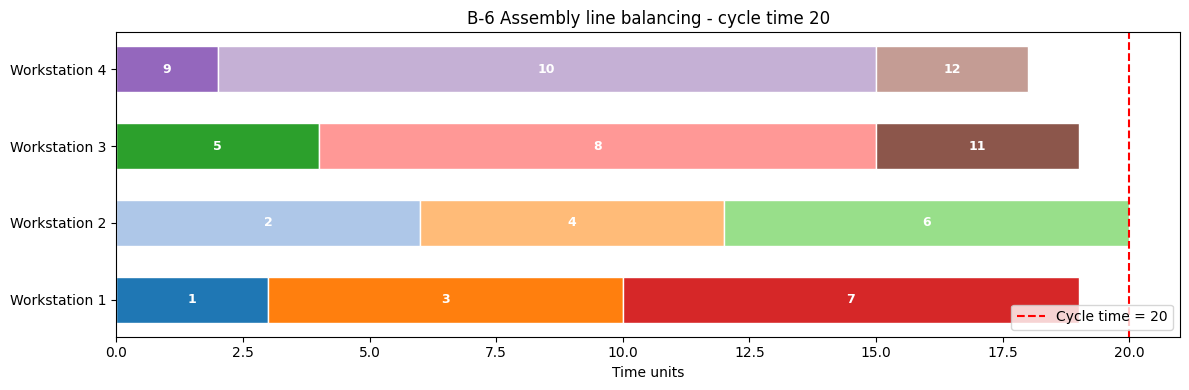

In [ ]:
if "process_df" in locals():
    DUR_b6 = [3, 6, 7, 6, 4, 8, 9, 11, 2, 13, 4, 3]
    task_colors = plt.cm.tab20.colors

    fig, ax = plt.subplots(figsize=(12, 4))
    for m in range(1, 5):
        tasks = sorted([i for i in range(1, 13) if process_df.at[i, m] > 0.5])
        left = 0
        for task in tasks:
            d = DUR_b6[task-1]
            ax.barh(m-1, d, left=left, color=task_colors[(task-1) % 20],
                    edgecolor="white", height=0.6)
            ax.text(left + d/2, m-1, str(task),
                    ha="center", va="center", fontsize=9, fontweight="bold", color="white")
            left += d

    ax.axvline(obj_val, color="red", linestyle="--", linewidth=1.5, label=f"Cycle time = {obj_val:.0f}")
    ax.set_yticks(range(4))
    ax.set_yticklabels([f"Workstation {m}" for m in range(1, 5)])
    ax.set_xlabel("Time units")
    ax.set_title(f"B-6 Assembly line balancing - cycle time {obj_val:.0f}")
    ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping workstation assignment chart")